In [10]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT KAGGLE DATA SOURCES
import kagglehub
asmahwimli_video_dataset_path = kagglehub.dataset_download('asmahwimli/video-dataset')

print('Data source import complete.')
print(asmahwimli_video_dataset_path)

Using Colab cache for faster access to the 'video-dataset' dataset.
Data source import complete.
/kaggle/input/video-dataset


In [5]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import os


In [11]:
root_dir=asmahwimli_video_dataset_path
all_metadata= pd.read_csv(os.path.join(root_dir, "all_metadata.csv"))

In [8]:
all_metadata

,Path_of_video,resolution,duration_seconds,content_parent_category,content_fine_category,youtube_title,youtube_description,text_to_speech_word_count,youtube_categories,youtube_tags,...,youtube_comment_count,youtube_like_count,youtube_channel_follower_count,youtube_upload_date,youtube_age_limit,content_metadata_title,content_metadata_description,Audio_embedding,Label,Audio_prediction
0,News_and_Politics/video_0.mp4,202x360,44.0,News and Politics,Celebrity Interviews,Drake Calling About Your Music Is An All-Time ...,@BurnaBoy was getting calls from The Boy in 20...,125.0,Entertainment,"burna boy drake, burna boy interview, burna bo...",...,601.0,48598.0,1590000.0,20220705.0,0.0,Video Analysis: Man 2's Journey to Music Success,"An engaging conversation between two men, wher...",NaN,NaN,NaN
1,News_and_Politics/video_1.mp4,480x360,45.0,News and Politics,Celebrity Interviews,"""Music Industry Demonic?"" - CHAKA KHAN On Whit...",NaN,112.0,Science and Technology,VIDEO0916,...,53.0,115.0,24600.0,20120214.0,0.0,Chaka Khan on Whitney Houston,A video analysis of Chaka Khan's criticism of ...,NaN,NaN,NaN
2,News_and_Politics/video_2.mp4,640x360,47.0,News and Politics,Expert Interviews,"""I was kind of a 'Joan Baez Marxist.'"" - Deird...","In this episode of Free Thoughts, Deirdre McCl...",74.0,News and Politics,"libertarian, libertarianism, libertarianismdot...",...,1.0,12.0,41200.0,20170713.0,0.0,Video Analysis: A Glimpse into Shifting Ideolo...,This video explores the shifting ideologies of...,NaN,NaN,NaN
3,News_and_Politics/video_3.mp4,360x360,41.0,News and Politics,Celebrity Interviews,Leonardo DiCaprio Try to Figure Out Which Wate...,#LeonardoDiCaprio\nLeo spent most of the inter...,77.0,Entertainment,"Leonardo DiCaprio, brad pitt, movie, leo",...,24.0,1490.0,5490.0,20210125.0,0.0,Video Analysis - Leonardo DiCaprio and Margot ...,A lighthearted and humorous interview featurin...,NaN,NaN,NaN
4,News_and_Politics/video_4.mp4,360x640,59.0,News and Politics,Political Commentary,Attorney DESTROYS a Karen who thinks child sup...,Are you tired of owning real estate in the bet...,217.0,Education,"21 convention, 21 studios, manosphere, fathers...",...,7800.0,114379.0,516000.0,20220724.0,0.0,A Woman's Perspective on Child Custody Complex...,The video showcases a woman discussing the cha...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7875,Entertainment/video_187.mp4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tf.Tensor(\n[[-0.37513605 0.06854776 0.12166...,3.0,7.0
7876,Entertainment/video_2.mp4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tf.Tensor(\n[[ 0.11896777 -0.3108711 -0.01182...,3.0,6.0
7877,Entertainment/video_317.mp4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tf.Tensor(\n[[-0.06671923 -0.18652734 1.14556...,3.0,4.0
7878,Entertainment/video_74.mp4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tf.Tensor(\n[[ 0.44074175 -0.17094675 -0.10782...,3.0,4.0


# Disribution of parent category:

In [12]:
category_counts=all_metadata['content_parent_category'].value_counts()
category_counts

,count
content_parent_category,
Lifestyle,502
Sports,501
Entertainment,500
Science and Technology,500
Hobbies and Interests,500
Education,500
News and Politics,499
Art and Creativity,250
Automotive,188


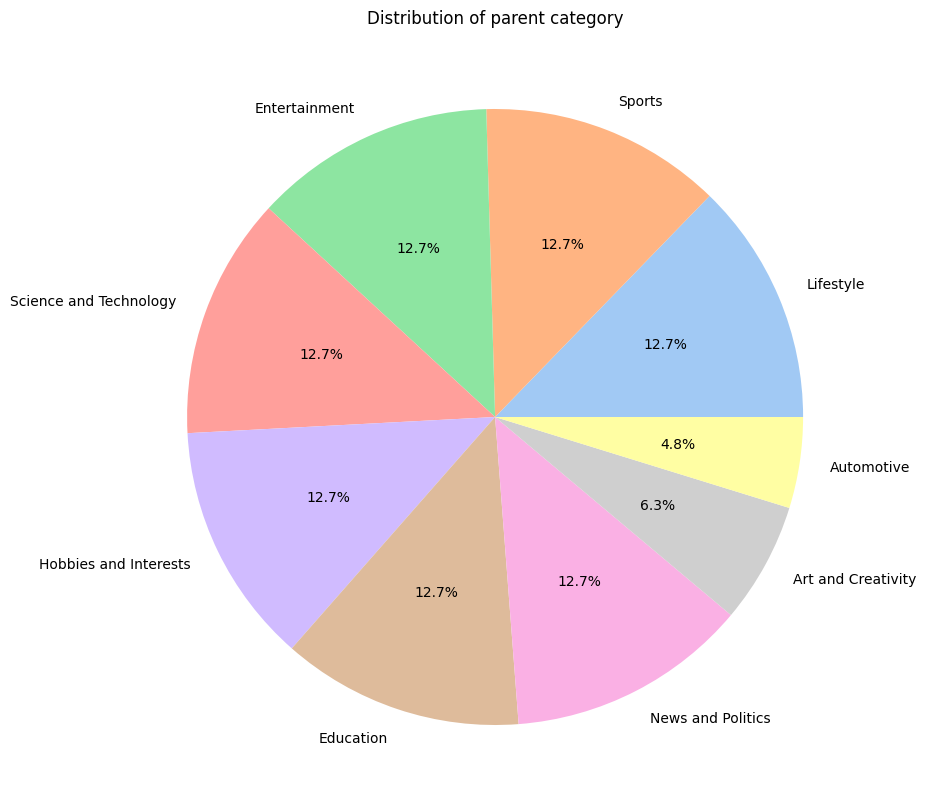

In [13]:
plt.figure(figsize=(10,10))
category_counts.plot(kind='pie', autopct='%1.1f%%',colors=sns.color_palette('pastel'))
plt.title("Distribution of parent category")
plt.ylabel('')
plt.savefig('distribution_of_parent_category.png', dpi=500)
plt.show()

# Distribution of fine category within each main parent category:

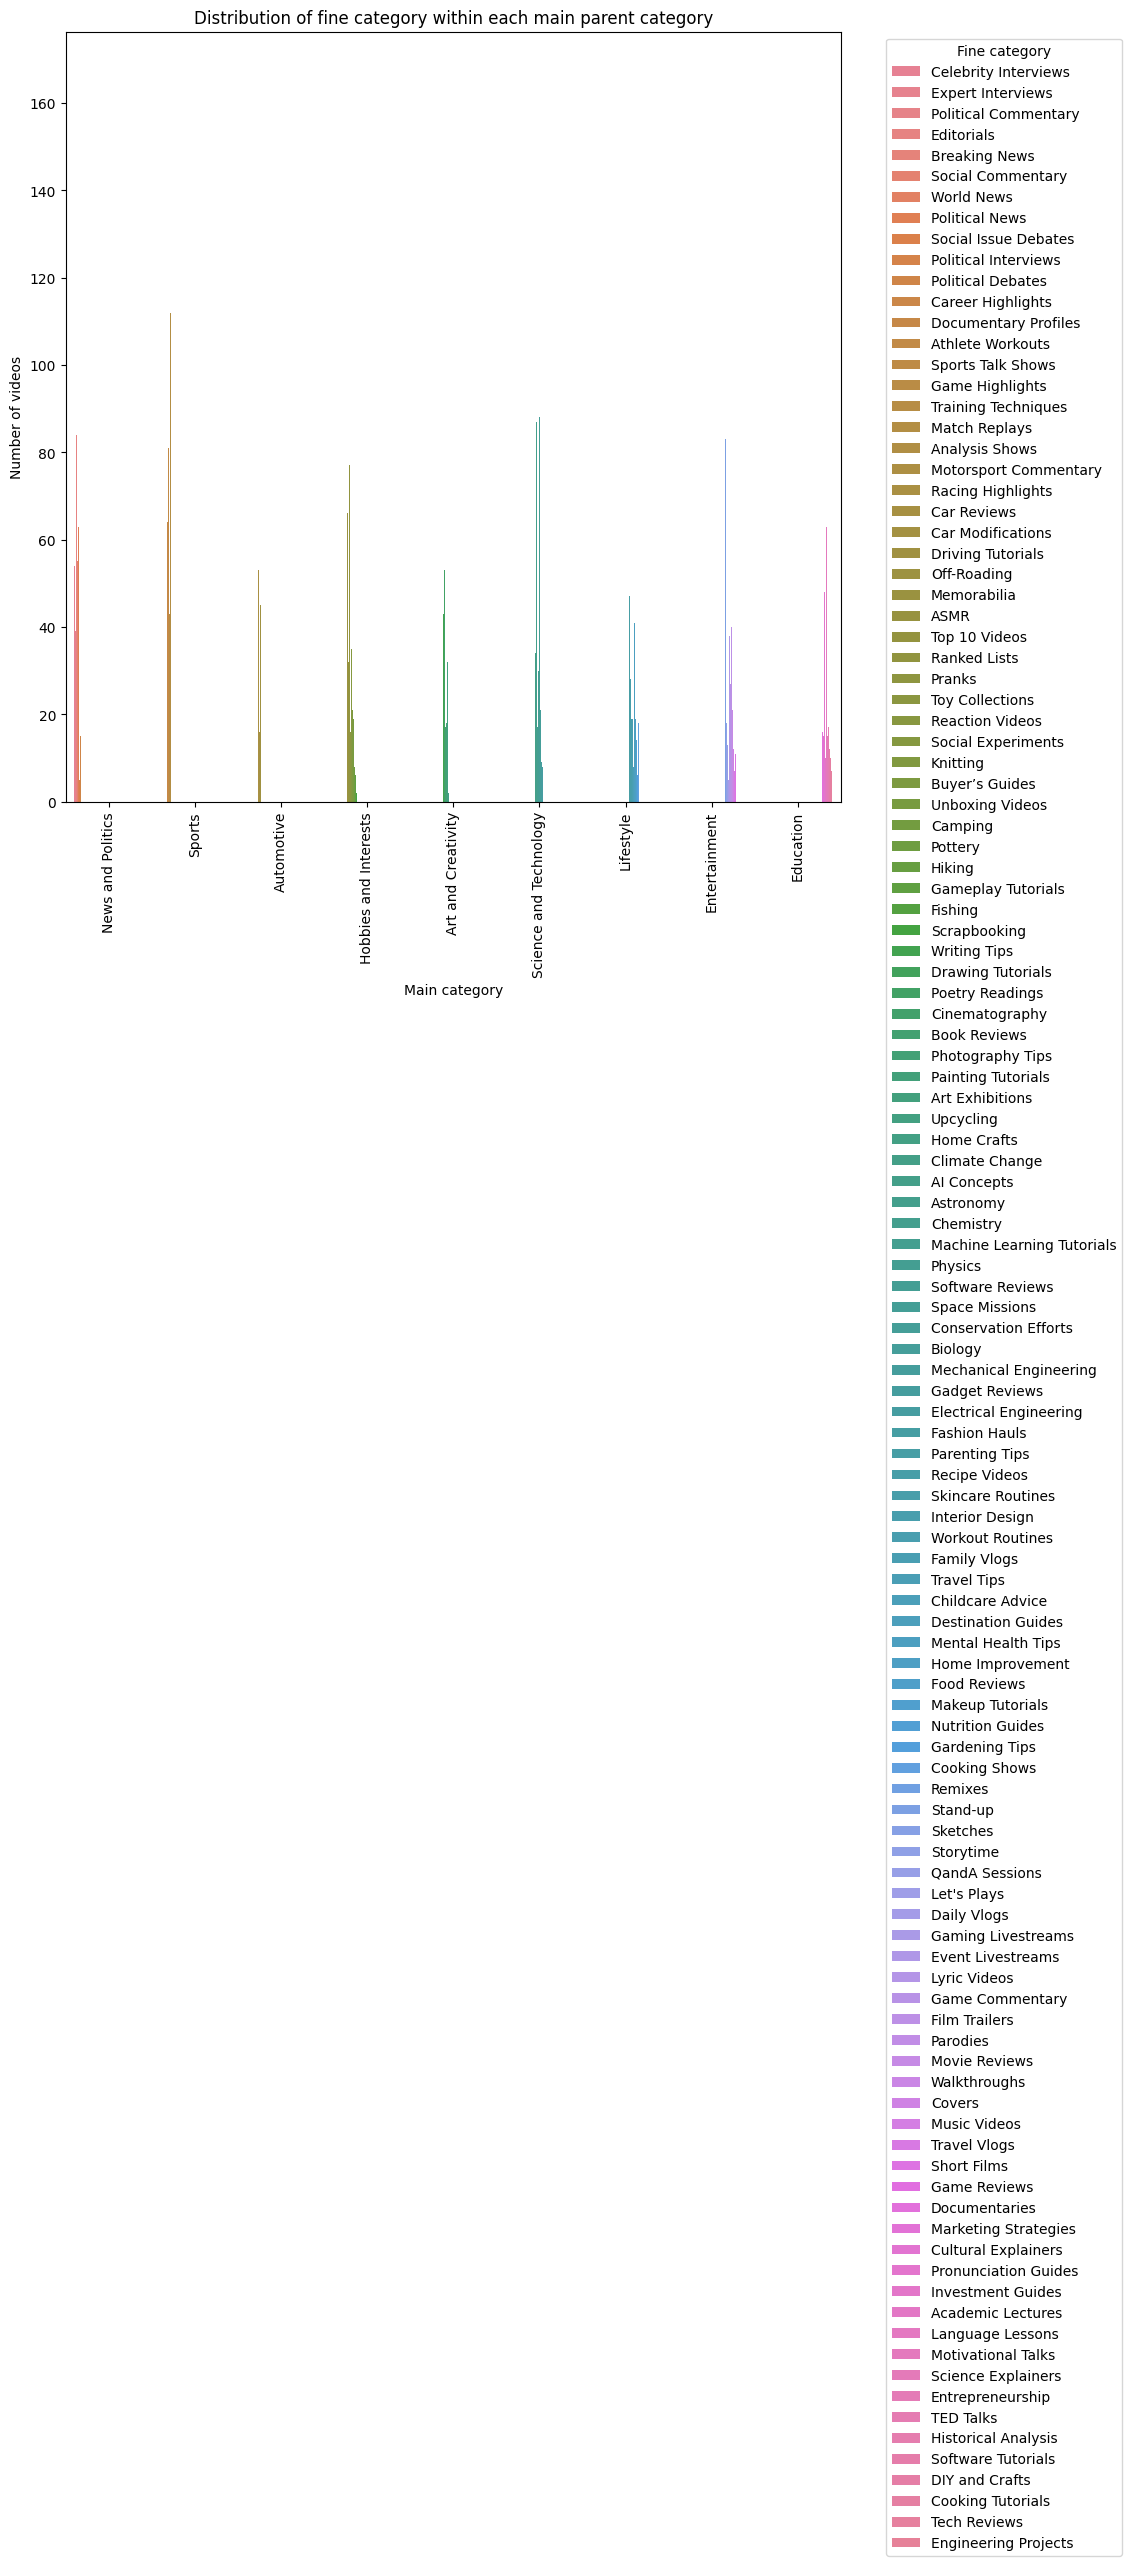

In [14]:
plt.figure(figsize=(10,10))
sns.countplot(data=all_metadata, x='content_parent_category', hue='content_fine_category')
plt.title("Distribution of fine category within each main parent category")
plt.xlabel("Main category")
plt.ylabel("Number of videos")
plt.xticks(rotation=90)
plt.legend(title="Fine category", bbox_to_anchor=(1.05,1), loc='upper left')
#plt.tight_layout()

plt.savefig('distribution_of_fine_category.png', dpi=300, bbox_inches='tight')
plt.show()

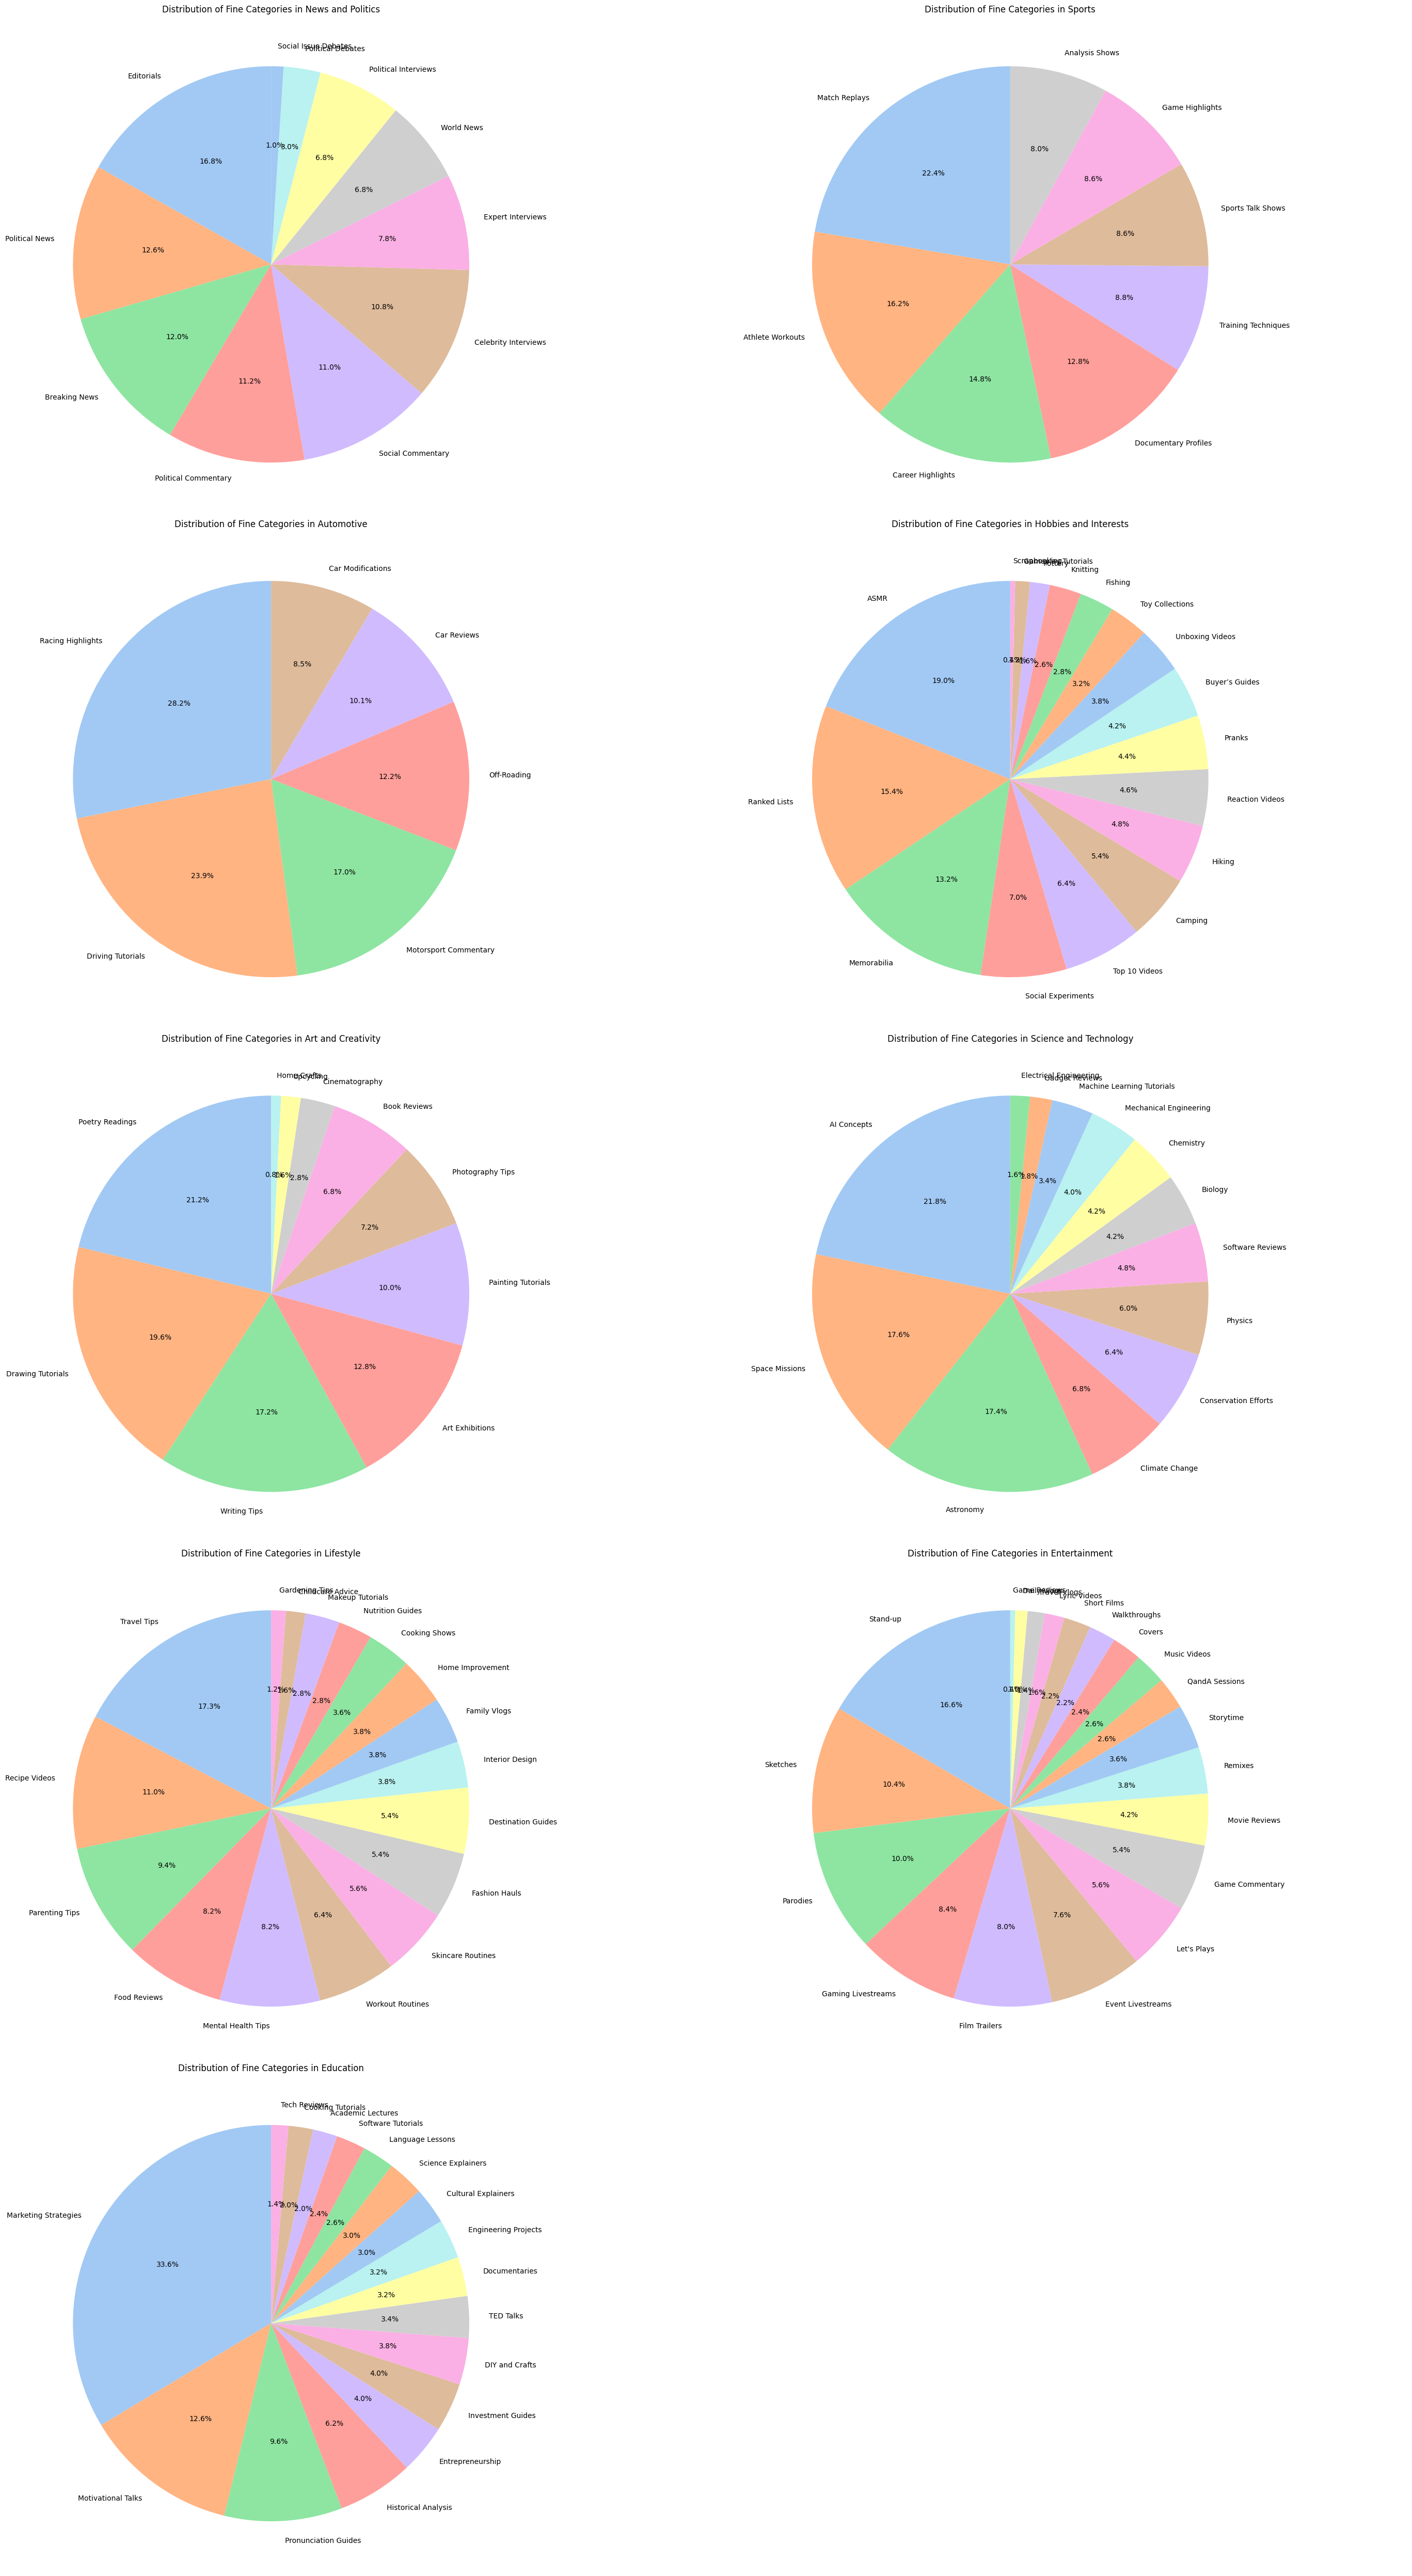

In [15]:
main_categories = all_metadata['content_parent_category'].unique()
num_categories = len(main_categories)
cols = 2  # Number of plots per row
rows = (num_categories // cols) + (num_categories % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(30, rows * 10))
axes = axes.flatten()

for i, main_category in enumerate(main_categories):
    fine_category_counts = all_metadata[all_metadata['content_parent_category'] == main_category]['content_fine_category'].value_counts()
    fine_category_counts.plot(kind='pie', ax=axes[i], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    axes[i].set_title(f'Distribution of Fine Categories in {main_category}')
    axes[i].set_ylabel('')  # Hide y-label for aesthetics

    # Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('distribution_of_fine_categories_by_parent.png', dpi=300, bbox_inches='tight')
plt.show()

# Duration in seconds of videos

In [16]:
durations=all_metadata['duration_seconds'].value_counts()

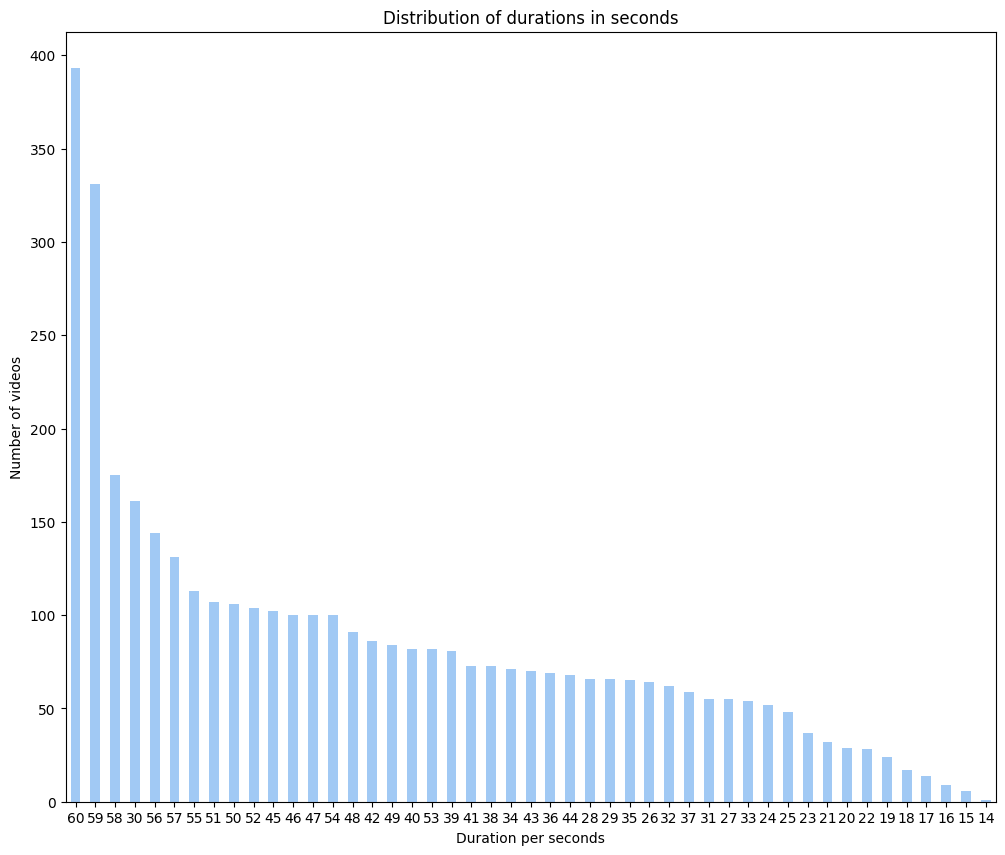

In [17]:
plt.figure(figsize=(12,10))
durations.plot(kind='bar', color=sns.color_palette('pastel')[0])
plt.title("Distribution of durations in seconds")
plt.xlabel("Duration per seconds")
plt.ylabel("Number of videos")
plt.xticks(rotation=0)
plt.savefig('distribution_of_durations.png', dpi=300, bbox_inches='tight')
plt.show()

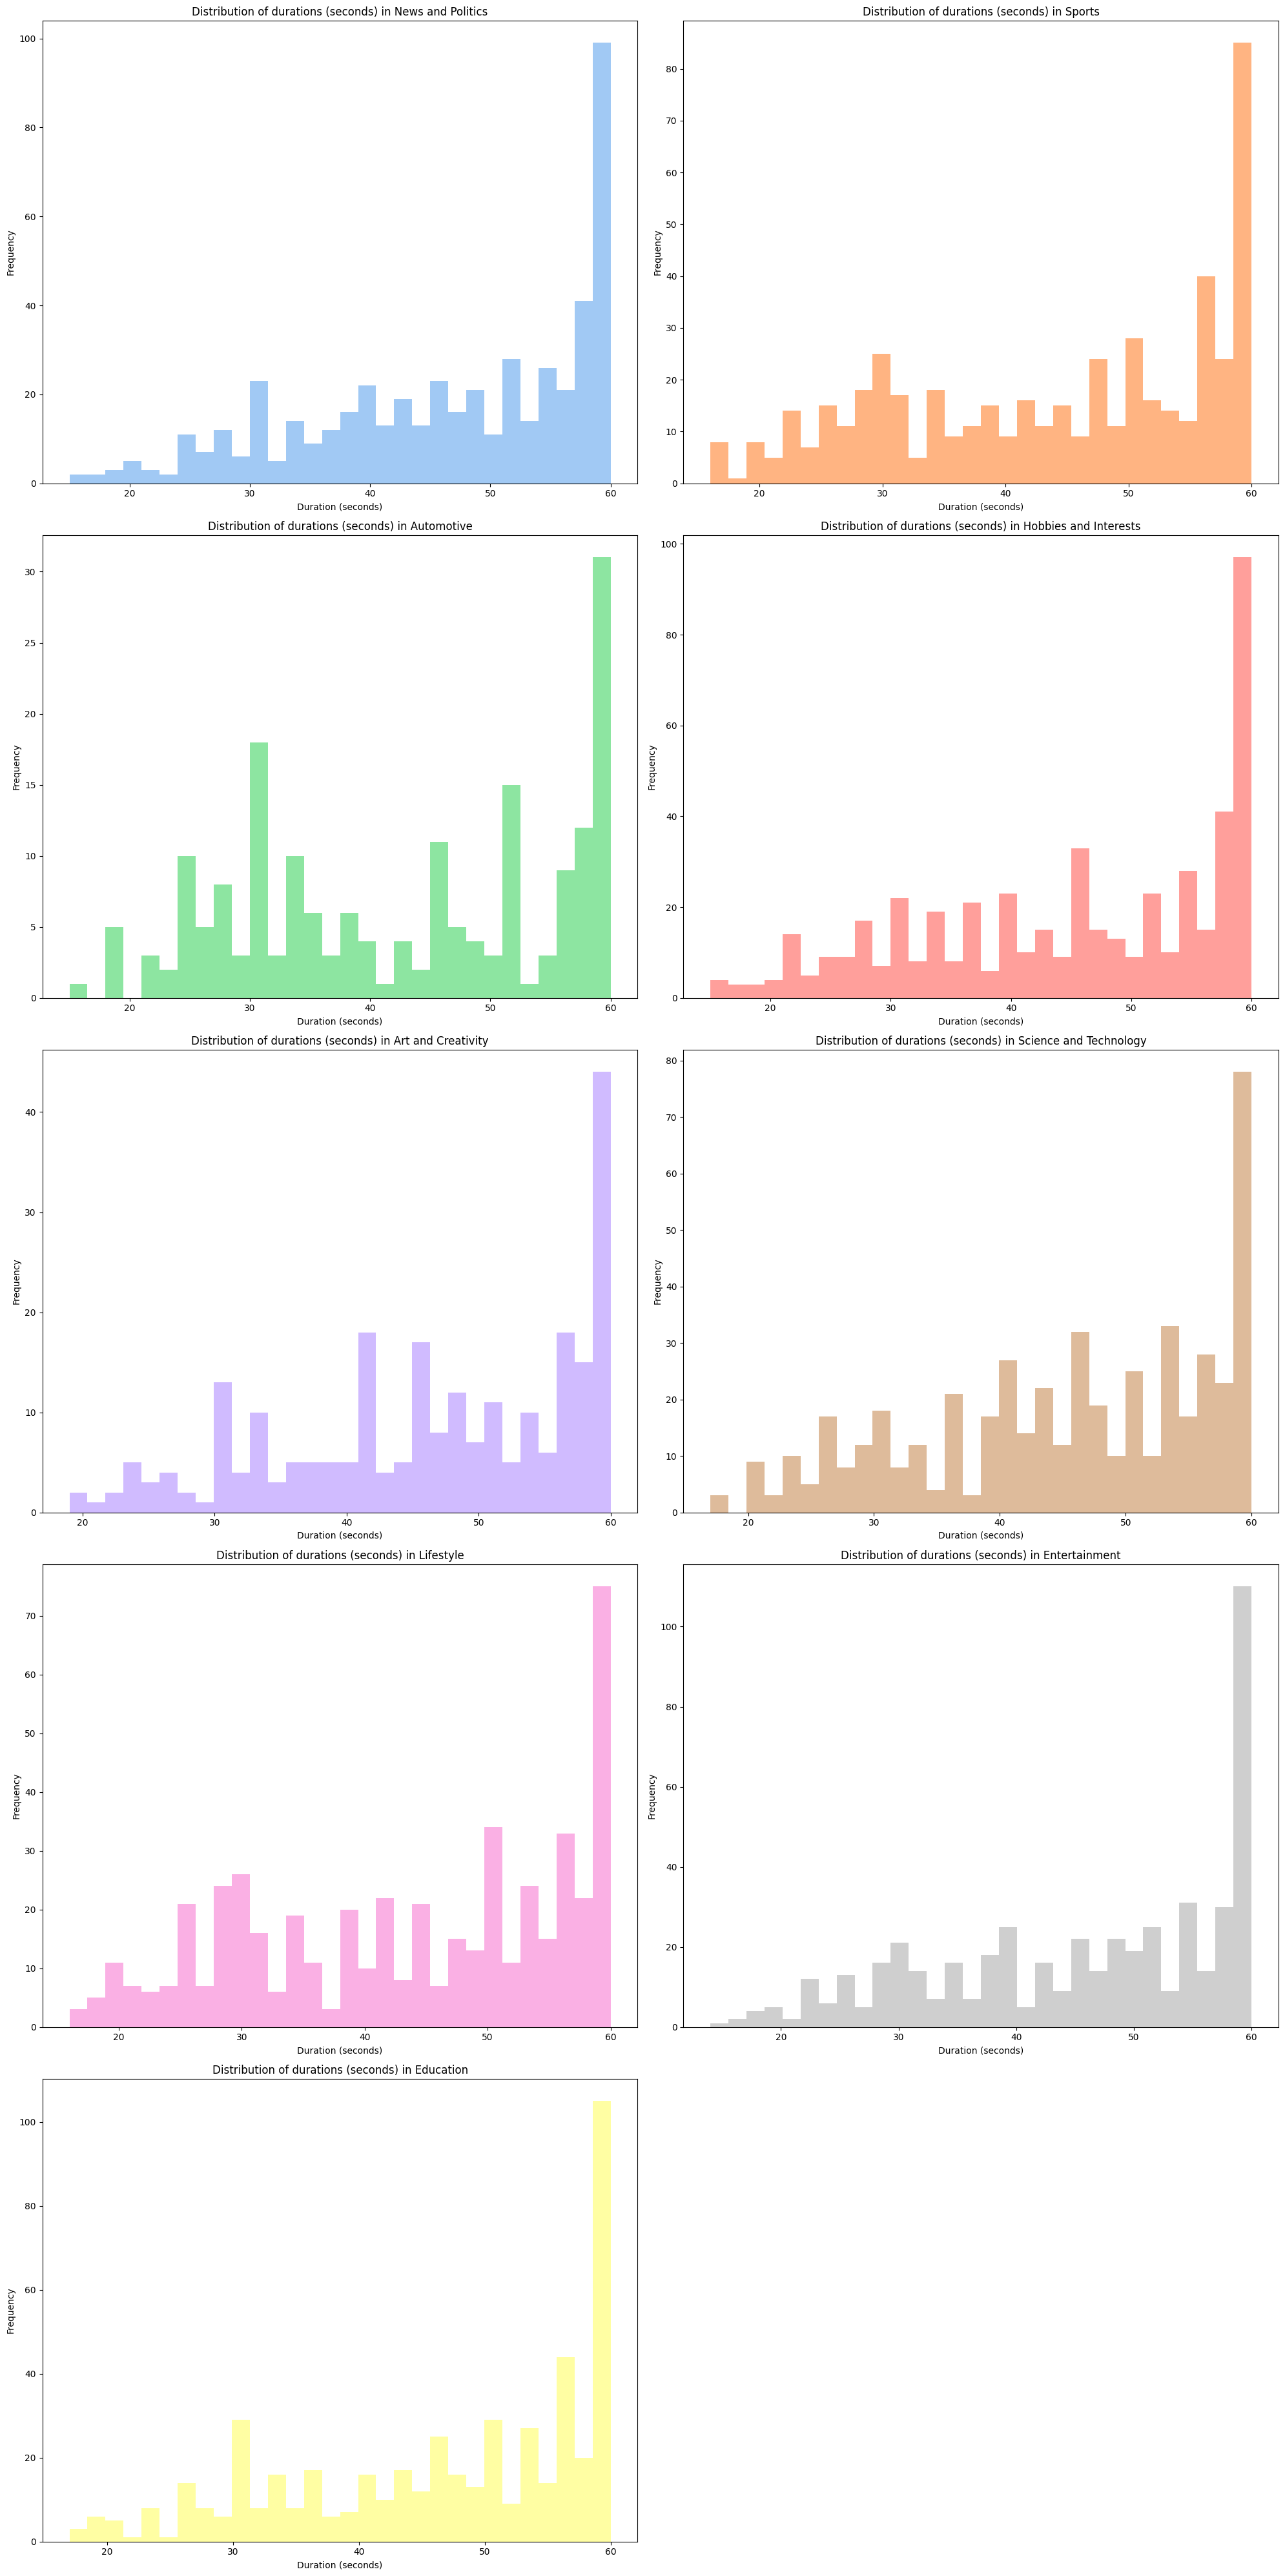

In [18]:
main_categories = all_metadata['content_parent_category'].unique()
num_categories = len(main_categories)
cols = 2  # Number of plots per row
rows = (num_categories // cols) + (num_categories % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 8))
axes = axes.flatten()

for i, main_category in enumerate(main_categories):
    fine_category_counts = all_metadata[all_metadata['content_parent_category'] == main_category]['duration_seconds']

    # Check if the category has data to plot
    if not fine_category_counts.empty:
        fine_category_counts.plot(kind='hist', bins=30, color=sns.color_palette('pastel')[i % len(sns.color_palette('pastel'))], ax=axes[i])
        axes[i].set_title(f'Distribution of durations (seconds) in {main_category}')
        axes[i].set_xlabel('Duration (seconds)')
        axes[i].set_ylabel('Frequency')

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('distribution_of_durations_by_category.png', dpi=300, bbox_inches='tight')
plt.show()
